<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20noClip001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Act XXXVII: Clipping Liberation
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
N = 1000              # lattice size
timesteps = 500       # evolution steps
lambda_val = 1.0      # compensatory coupling
seed = 42
np.random.seed(seed)

# Initial conditions: random amplitudes
state = np.random.normal(0, 1, N)


In [3]:
def evolve(state, timesteps, lambda_val, clip=True):
    history = []
    s = state.copy()
    for t in range(timesteps):
        # Update rule: simple attractor kernel
        s = s + lambda_val * np.sin(s)

        # Apply clipping if enabled
        if clip:
            s = np.clip(s, -5, 5)

        history.append(s.copy())
    return np.array(history)

# Run with clipping
history_clipped = evolve(state, timesteps, lambda_val, clip=True)


In [4]:
# Run without clipping
history_liberated = evolve(state, timesteps, lambda_val, clip=False)


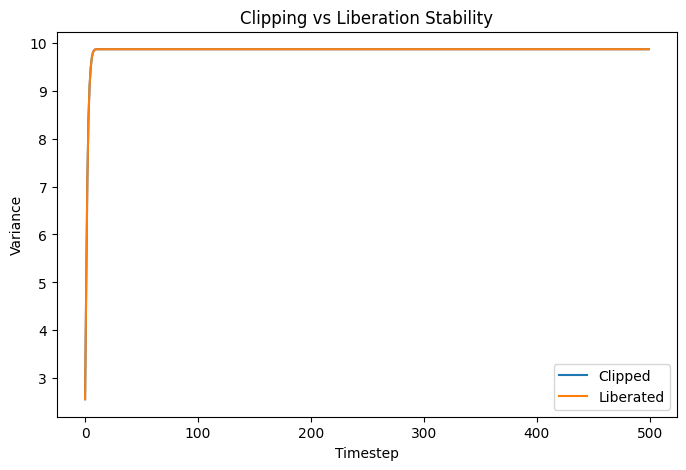

In [5]:
def stability_metric(history):
    # Measure variance growth over time
    variances = np.var(history, axis=1)
    return variances

var_clipped = stability_metric(history_clipped)
var_liberated = stability_metric(history_liberated)

plt.figure(figsize=(8,5))
plt.plot(var_clipped, label="Clipped")
plt.plot(var_liberated, label="Liberated")
plt.xlabel("Timestep")
plt.ylabel("Variance")
plt.title("Clipping vs Liberation Stability")
plt.legend()
plt.show()


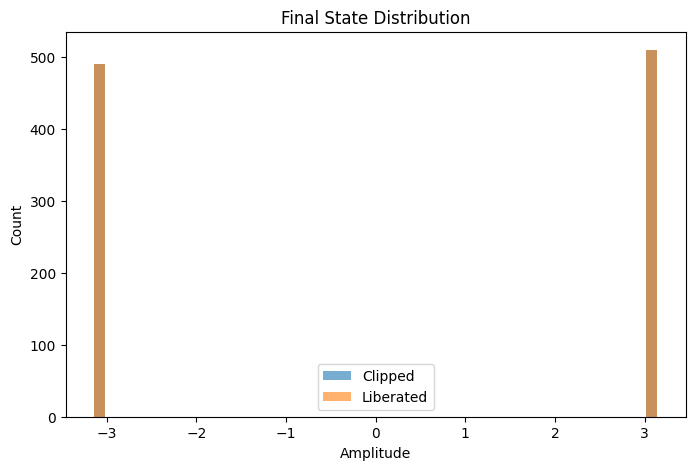

In [6]:
# Compare final distributions
plt.figure(figsize=(8,5))
plt.hist(history_clipped[-1], bins=50, alpha=0.6, label="Clipped")
plt.hist(history_liberated[-1], bins=50, alpha=0.6, label="Liberated")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.title("Final State Distribution")
plt.legend()
plt.show()
